In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2

import numpy as np
import pandas as pd
import os
import glob
import zipfile
import shutil

from PIL import Image
import cv2

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              f1_score, precision_score, recall_score)
from sklearn.utils import class_weight

import warnings
warnings.filterwarnings('ignore')
import random
import time

from google.colab import drive
drive.mount('/content/drive')

print("TensorFlow Version :", tf.__version__)
print("GPU Available       :", tf.config.list_physical_devices('GPU'))
print("All libraries loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow Version : 2.19.0
GPU Available       : []
All libraries loaded successfully!


In [2]:
base_dir  = '/content/drive/MyDrive/Archive'
train_dir = base_dir + '/train'
val_dir   = base_dir + '/val'
test_dir  = base_dir + '/test'

print("Train dir:", train_dir)
print("Val dir  :", val_dir)
print("Test dir :", test_dir)

Train dir: /content/drive/MyDrive/Archive/train
Val dir  : /content/drive/MyDrive/Archive/val
Test dir : /content/drive/MyDrive/Archive/test


In [3]:
import os

for split in ['train', 'val', 'test']:
    for category in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(base_dir, split, category)
        count = len(os.listdir(path))
        print(f"{split} / {category} : {count} images")


train / NORMAL : 1341 images
train / PNEUMONIA : 3890 images
val / NORMAL : 8 images
val / PNEUMONIA : 8 images
test / NORMAL : 234 images
test / PNEUMONIA : 390 images


In [4]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array([0]*1341 + [1]*3875)
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print("Train samples :", train_generator.samples)
print("Val samples   :", val_generator.samples)
print("Test samples  :", test_generator.samples)
print("Classes       :", train_generator.class_indices)

Found 5231 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train samples : 5231
Val samples   : 16
Test samples  : 624
Classes       : {'NORMAL': 0, 'PNEUMONIA': 1}


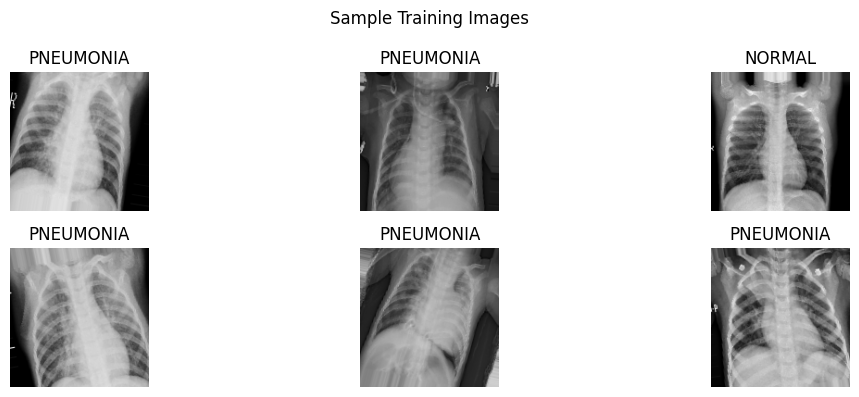

In [6]:
def plot_sample_images(generator, title):
    images, labels = next(generator)
    plt.figure(figsize=(12, 4))
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i])
        plt.title('NORMAL' if labels[i] == 0 else 'PNEUMONIA')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_sample_images(train_generator, 'Sample Training Images')

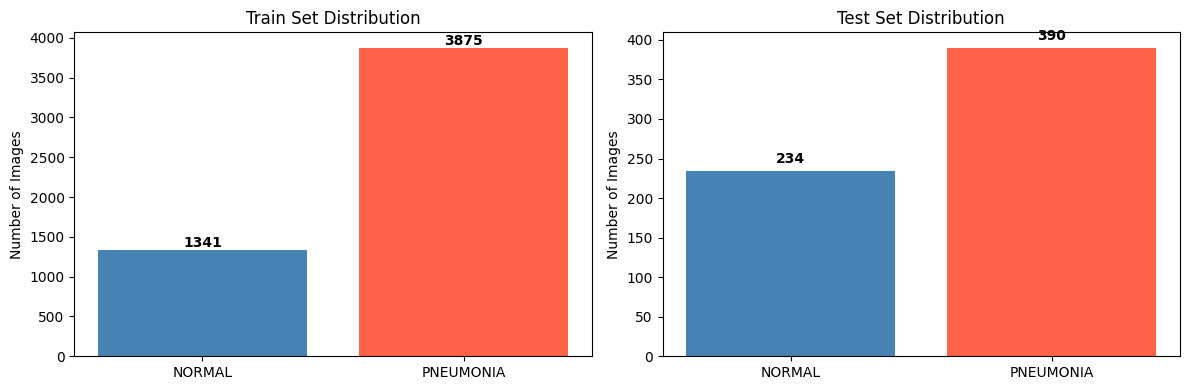

In [7]:

labels = ['NORMAL', 'PNEUMONIA']
train_counts = [1341, 3875]
test_counts  = [234, 390]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, train_counts, color=['steelblue', 'tomato'])
axes[0].set_title('Train Set Distribution')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(train_counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].bar(labels, test_counts, color=['steelblue', 'tomato'])
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Number of Images')
for i, v in enumerate(test_counts):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:

from tensorflow.keras.regularizers import l2

model = Sequential([

    Conv2D(32, (3,3), activation='tanh', padding='same', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='tanh', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='tanh', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='tanh', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    GlobalAveragePooling2D(),

    Dense(256, activation='tanh', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='tanh', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           51

 Total params: 490,689 (1.87 MB)

 Trainable params: 488,961 (1.87 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [9]:
from tensorflow.keras import backend as K

def f1_score_metric(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float'), axis=0)
    fp = K.sum(K.cast((1 - y_true) * y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true * (1 - y_pred), 'float'), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall    = tp / (tp + fn + K.epsilon())
    f1        = 2 * precision * recall / (precision + recall + K.epsilon())
    return K.mean(f1)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        f1_score_metric
    ]
)


In [11]:
callbacks = [
    EarlyStopping(
        monitor='val_recall',
        patience=5,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_recall',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

In [12]:

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7254 - auc: 0.8602 - f1_score_metric: 0.5070 - loss: 0.9661 - precision: 0.9389 - recall: 0.6705
Epoch 1: val_recall improved from None to 1.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 1494s 9s/step - accuracy: 0.7744 - auc: 0.8911 - f1_score_metric: 0.5390 - loss: 0.8731 - precision: 0.9538 - recall: 0.7321 - val_accuracy: 0.5000 - val_auc: 0.6406 - val_f1_score_metric: 0.5000 - val_loss: 3.2081 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8375 - auc: 0.9238 - f1_score_metric: 0.5757 - loss: 0.7439 - precision: 0.9569 - recall: 0.8181
Epoch 2: val_recall did not improve from 1.00000
164/164 ━━━━━━━━━━━━━━━━━━━━ 669s 4s/step - accuracy: 0.8457 - auc: 0.9316 - f1_score_metric: 0.5799 - loss: 0.7143 - precision: 0.9600 - recall: 0.8270 - val_accuracy: 0.5000 - 

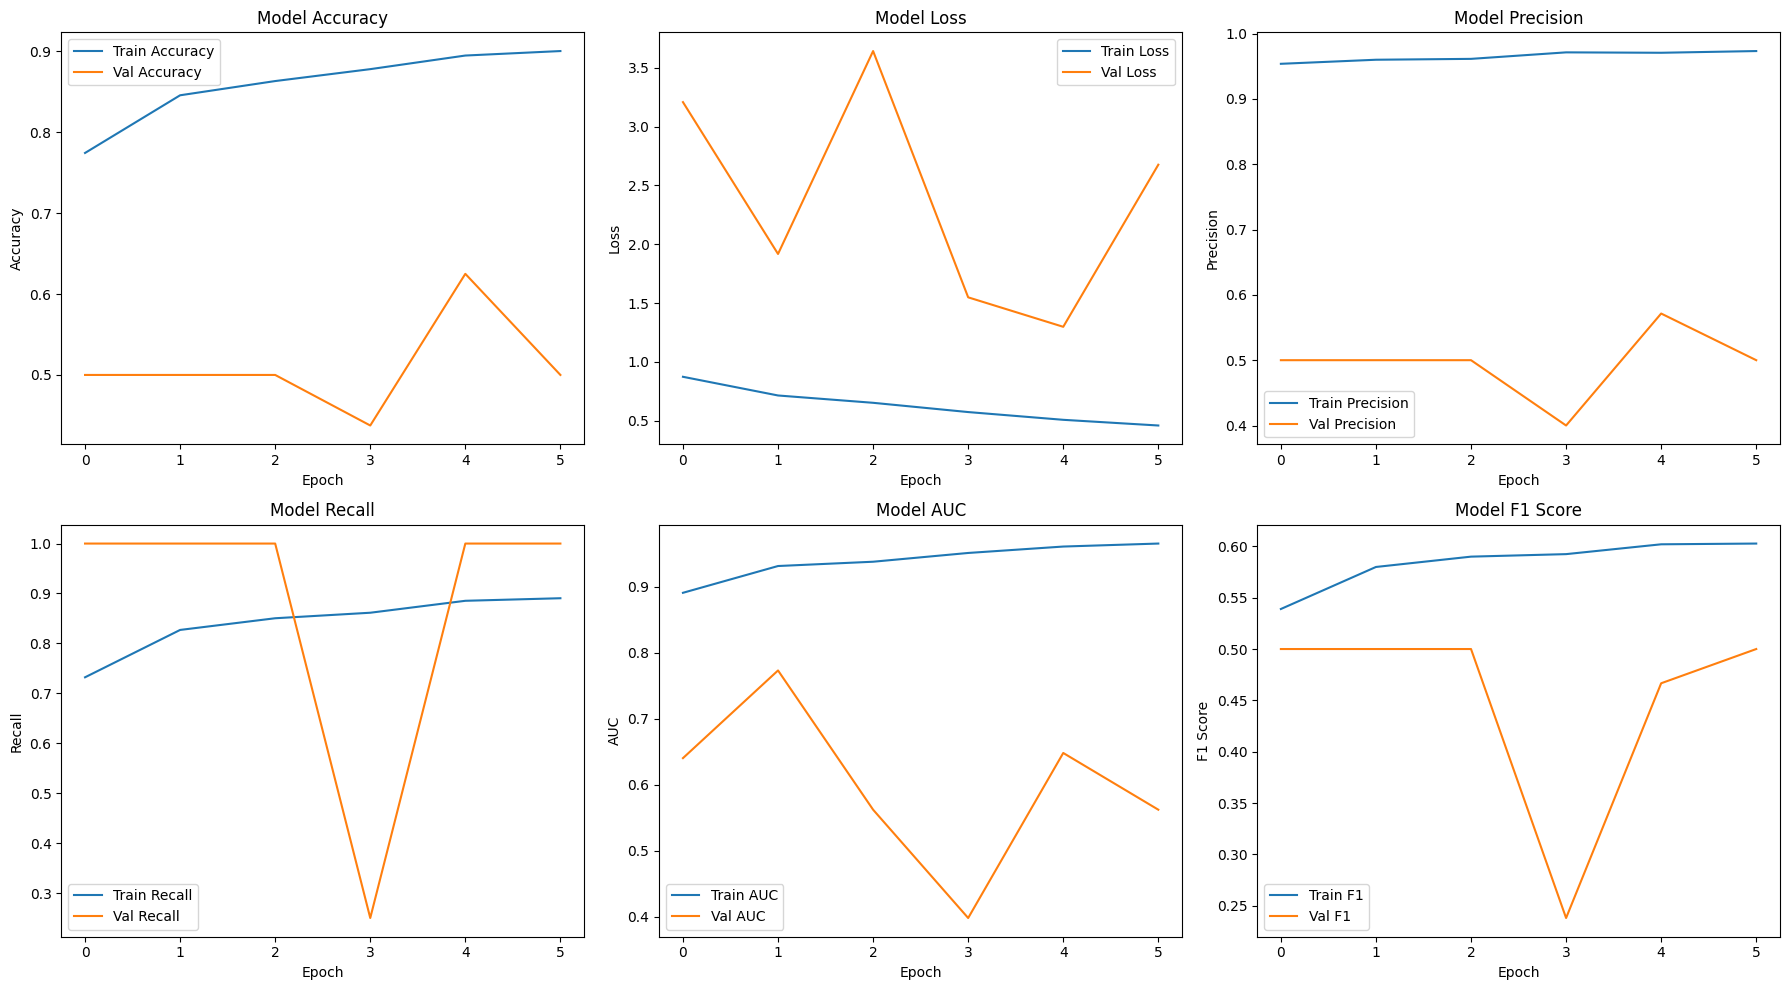

In [13]:

def plot_training_history(history):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0,0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0,0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0,0].set_title('Model Accuracy')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].legend()

    axes[0,1].plot(history.history['loss'],     label='Train Loss')
    axes[0,1].plot(history.history['val_loss'], label='Val Loss')
    axes[0,1].set_title('Model Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].legend()

    axes[0,2].plot(history.history['precision'],     label='Train Precision')
    axes[0,2].plot(history.history['val_precision'], label='Val Precision')
    axes[0,2].set_title('Model Precision')
    axes[0,2].set_xlabel('Epoch')
    axes[0,2].set_ylabel('Precision')
    axes[0,2].legend()

    axes[1,0].plot(history.history['recall'],     label='Train Recall')
    axes[1,0].plot(history.history['val_recall'], label='Val Recall')
    axes[1,0].set_title('Model Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Recall')
    axes[1,0].legend()

    axes[1,1].plot(history.history['auc'],     label='Train AUC')
    axes[1,1].plot(history.history['val_auc'], label='Val AUC')
    axes[1,1].set_title('Model AUC')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('AUC')
    axes[1,1].legend()

    axes[1,2].plot(history.history['f1_score_metric'],     label='Train F1')
    axes[1,2].plot(history.history['val_f1_score_metric'], label='Val F1')
    axes[1,2].set_title('Model F1 Score')
    axes[1,2].set_xlabel('Epoch')
    axes[1,2].set_ylabel('F1 Score')
    axes[1,2].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)


In [20]:
print(f"\nTest Accuracy  : {results[1]:.4f}")
print(f"Test Precision : {results[2]:.4f}")
print(f"Test Recall    : {results[3]:.4f}")
print(f"Test AUC       : {results[4]:.4f}")
print(f"Test F1 Score  : {results[5]:.4f}")

y_pred_prob = model.predict(test_generator)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
y_true      = test_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))



Test Accuracy  : 0.6250
Test Precision : 0.6250
Test Recall    : 1.0000
Test AUC       : 0.5410
Test F1 Score  : 0.6344
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



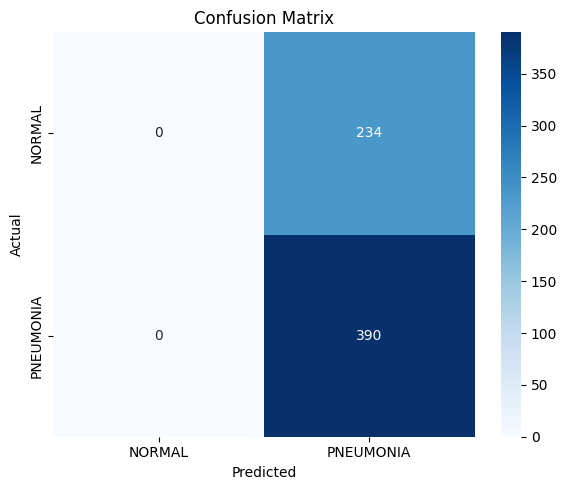


True Negatives  (TN) : 0
False Positives (FP) : 234
False Negatives (FN) : 0  ← Most critical in medical!
True Positives  (TP) : 390

Sensitivity (Recall) : 1.0000
Specificity          : 0.0000


In [21]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"\nTrue Negatives  (TN) : {tn}")
print(f"False Positives (FP) : {fp}")
print(f"False Negatives (FN) : {fn}  ← Most critical in medical!")
print(f"True Positives  (TP) : {tp}")
print(f"\nSensitivity (Recall) : {sensitivity:.4f}")
print(f"Specificity          : {specificity:.4f}")

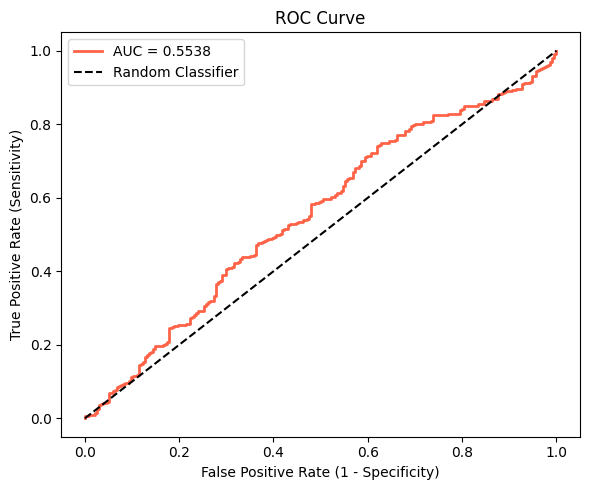

ROC AUC Score : 0.5538


In [22]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
auc_score = roc_auc_score(y_true, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='tomato', linewidth=2, label=f'AUC = {auc_score:.4f}')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC AUC Score : {auc_score:.4f}")

In [23]:

print("="*50)
print("         FINAL MODEL PERFORMANCE SUMMARY")
print("="*50)
print(f"Accuracy    : {results[1]:.4f}")
print(f"Precision   : {results[2]:.4f}")
print(f"Recall      : {results[3]:.4f}")
print(f"AUC         : {results[4]:.4f}")
print(f"F1 Score    : {results[5]:.4f}")
print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"ROC AUC     : {auc_score:.4f}")
print("="*50)

         FINAL MODEL PERFORMANCE SUMMARY
Accuracy    : 0.6250
Precision   : 0.6250
Recall      : 1.0000
AUC         : 0.5410
F1 Score    : 0.6344
Sensitivity : 1.0000
Specificity : 0.0000
ROC AUC     : 0.5538
